In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import shutil
from PIL import Image
import json

In [3]:
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow Version: 2.19.1
GPU Available: []


In [5]:
IMG_SIZE = 224
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
EPOCHS_PHASE1 = 25
EPOCHS_PHASE2 = 35

# UPDATE THESE PATHS
ORIGINAL_DATA_DIR = r"D:\Satyam\My sub,apps,AI Apps\My subjects\PROJECT 8TH SEM\chest_xray\chest_xray"
NEW_DATA_DIR = "chest_xray_3class"  # New directory with 3 classes

# Paths for original data
ORIGINAL_TRAIN = os.path.join(ORIGINAL_DATA_DIR, "train")
ORIGINAL_VAL = os.path.join(ORIGINAL_DATA_DIR, "val")
ORIGINAL_TEST = os.path.join(ORIGINAL_DATA_DIR, "test")

In [6]:
NEW_TRAIN = os.path.join(NEW_DATA_DIR, "train")
NEW_VAL = os.path.join(NEW_DATA_DIR, "val")
NEW_TEST = os.path.join(NEW_DATA_DIR, "test")

In [7]:
CHECKPOINT_DIR = "checkpoints_3class"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"\n{'='*70}")
print(f"Three-Class Pneumonia Detection Model")
print(f"{'='*70}")
print(f"Classes: NORMAL, PNEUMONIA, NOT_XRAY")
print(f"{'='*70}\n")


Three-Class Pneumonia Detection Model
Classes: NORMAL, PNEUMONIA, NOT_XRAY



In [8]:
def download_not_xray_images():
    """
    Creates a dataset of normal images (NOT X-rays) for the third class.
    Uses publicly available image datasets.
    """
    print("\n" + "="*70)
    print("CREATING NOT_XRAY DATASET")
    print("="*70)
    
    # We'll use a combination of methods to get normal images
    # Method 1: Generate synthetic normal images
    # Method 2: Use sample images from common datasets
    
    not_xray_dir_train = os.path.join(NEW_TRAIN, "NOT_XRAY")
    not_xray_dir_val = os.path.join(NEW_VAL, "NOT_XRAY")
    not_xray_dir_test = os.path.join(NEW_TEST, "NOT_XRAY")
    
    os.makedirs(not_xray_dir_train, exist_ok=True)
    os.makedirs(not_xray_dir_val, exist_ok=True)
    os.makedirs(not_xray_dir_test, exist_ok=True)
    
    # Generate synthetic normal images (people, nature, objects)
    def create_synthetic_images(output_dir, num_images):
        """Create synthetic images that are clearly NOT X-rays"""
        for i in range(num_images):
            # Create random colored images (unlike grayscale X-rays)
            img_type = i % 5
            
            if img_type == 0:  # Colorful gradient
                img = np.zeros((224, 224, 3), dtype=np.uint8)
                for x in range(224):
                    for y in range(224):
                        img[x, y] = [x % 256, y % 256, (x+y) % 256]
            
            elif img_type == 1:  # Random noise (color photo style)
                img = np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)
                # Add some structure
                img = cv2.GaussianBlur(img, (15, 15), 0)
            
            elif img_type == 2:  # Geometric patterns
                img = np.zeros((224, 224, 3), dtype=np.uint8)
                colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)]
                for j in range(10):
                    pt1 = (np.random.randint(0, 224), np.random.randint(0, 224))
                    pt2 = (np.random.randint(0, 224), np.random.randint(0, 224))
                    color = colors[np.random.randint(0, 4)]
                    cv2.line(img, pt1, pt2, color, np.random.randint(2, 10))
            
            elif img_type == 3:  # Circles and shapes
                img = np.ones((224, 224, 3), dtype=np.uint8) * 255
                for j in range(5):
                    center = (np.random.randint(30, 194), np.random.randint(30, 194))
                    radius = np.random.randint(10, 50)
                    color = tuple(np.random.randint(0, 256, 3).tolist())
                    cv2.circle(img, center, radius, color, -1)
            
            else:  # Text-like patterns
                img = np.ones((224, 224, 3), dtype=np.uint8) * 255
                for j in range(20):
                    pt1 = (np.random.randint(10, 200), np.random.randint(10, 200))
                    text = chr(65 + np.random.randint(0, 26))
                    cv2.putText(img, text, pt1, cv2.FONT_HERSHEY_SIMPLEX, 
                               1, (0, 0, 0), 2)
            
            # Save image
            img_path = os.path.join(output_dir, f"not_xray_{i:04d}.jpg")
            cv2.imwrite(img_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
        
        print(f"✅ Created {num_images} synthetic NOT_XRAY images in {output_dir}")
    
    # Create images for each split
    # We want roughly same number as other classes
    create_synthetic_images(not_xray_dir_train, 2000)  # For training
    create_synthetic_images(not_xray_dir_val, 100)     # For validation
    create_synthetic_images(not_xray_dir_test, 300)    # For testing
    
    print(f"\n✅ NOT_XRAY dataset created successfully!")
    return True

In [9]:
# ============================================================================
# STEP 3: REORGANIZE DATASET TO 3 CLASSES
# ============================================================================

def create_3class_dataset():
    """
    Reorganizes the dataset to have 3 classes:
    - NORMAL (from original NORMAL X-rays)
    - PNEUMONIA (from original PNEUMONIA X-rays)
    - NOT_XRAY (generated synthetic images)
    """
    print("\n" + "="*70)
    print("REORGANIZING DATASET TO 3 CLASSES")
    print("="*70)
    
    # Create directories
    for split in ['train', 'val', 'test']:
        for class_name in ['NORMAL', 'PNEUMONIA', 'NOT_XRAY']:
            os.makedirs(os.path.join(NEW_DATA_DIR, split, class_name), exist_ok=True)
    
    # Copy NORMAL and PNEUMONIA from original dataset
    splits = [
        (ORIGINAL_TRAIN, NEW_TRAIN),
        (ORIGINAL_VAL, NEW_VAL),
        (ORIGINAL_TEST, NEW_TEST)
    ]
    
    for original, new in splits:
        for class_name in ['NORMAL', 'PNEUMONIA']:
            src = os.path.join(original, class_name)
            dst = os.path.join(new, class_name)
            
            if os.path.exists(src):
                # Copy all images
                images = os.listdir(src)
                for img in images:
                    src_path = os.path.join(src, img)
                    dst_path = os.path.join(dst, img)
                    if not os.path.exists(dst_path):
                        shutil.copy2(src_path, dst_path)
                
                print(f"✅ Copied {len(images)} {class_name} images to {new}")
    
    # Create NOT_XRAY images
    download_not_xray_images()
    
    # Count final dataset
    print(f"\n{'='*70}")
    print(f"Final 3-Class Dataset Statistics")
    print(f"{'='*70}")
    
    for split in ['train', 'val', 'test']:
        split_dir = os.path.join(NEW_DATA_DIR, split)
        print(f"\n{split.upper()} SET:")
        total = 0
        for class_name in ['NORMAL', 'PNEUMONIA', 'NOT_XRAY']:
            class_dir = os.path.join(split_dir, class_name)
            count = len(os.listdir(class_dir))
            total += count
            print(f"  {class_name}: {count} images")
        print(f"  TOTAL: {total} images")
    
    print(f"\n{'='*70}\n")
    return True

# Create the 3-class dataset
if not os.path.exists(NEW_DATA_DIR):
    create_3class_dataset()
else:
    print(f"\n✅ 3-class dataset already exists at: {NEW_DATA_DIR}")
    # Show statistics
    for split in ['train', 'val', 'test']:
        split_dir = os.path.join(NEW_DATA_DIR, split)
        print(f"\n{split.upper()} SET:")
        for class_name in ['NORMAL', 'PNEUMONIA', 'NOT_XRAY']:
            class_dir = os.path.join(split_dir, class_name)
            if os.path.exists(class_dir):
                count = len(os.listdir(class_dir))
                print(f"  {class_name}: {count} images")


REORGANIZING DATASET TO 3 CLASSES
✅ Copied 1266 NORMAL images to chest_xray_3class\train
✅ Copied 3418 PNEUMONIA images to chest_xray_3class\train
✅ Copied 158 NORMAL images to chest_xray_3class\val
✅ Copied 427 PNEUMONIA images to chest_xray_3class\val
✅ Copied 159 NORMAL images to chest_xray_3class\test
✅ Copied 428 PNEUMONIA images to chest_xray_3class\test

CREATING NOT_XRAY DATASET
✅ Created 2000 synthetic NOT_XRAY images in chest_xray_3class\train\NOT_XRAY
✅ Created 100 synthetic NOT_XRAY images in chest_xray_3class\val\NOT_XRAY
✅ Created 300 synthetic NOT_XRAY images in chest_xray_3class\test\NOT_XRAY

✅ NOT_XRAY dataset created successfully!

Final 3-Class Dataset Statistics

TRAIN SET:
  NORMAL: 1266 images
  PNEUMONIA: 3418 images
  NOT_XRAY: 2000 images
  TOTAL: 6684 images

VAL SET:
  NORMAL: 158 images
  PNEUMONIA: 427 images
  NOT_XRAY: 100 images
  TOTAL: 685 images

TEST SET:
  NORMAL: 159 images
  PNEUMONIA: 428 images
  NOT_XRAY: 300 images
  TOTAL: 887 images




In [10]:
# ============================================================================
# STEP 4: CREATE DATA GENERATORS
# ============================================================================

print("\n" + "="*70)
print("CREATING DATA GENERATORS")
print("="*70)

# Training augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range=[0.8, 1.2]
)

# Validation augmentation (light)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=5,
    horizontal_flip=True
)

# Test (no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators
train_generator = train_datagen.flow_from_directory(
    NEW_TRAIN,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    NEW_VAL,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    NEW_TEST,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\n✅ Generators Created:")
print(f"Training batches: {len(train_generator)}")
print(f"Validation batches: {len(val_generator)}")
print(f"Test batches: {len(test_generator)}")
print(f"\nClass indices: {train_generator.class_indices}")
print(f"{'='*70}\n")


CREATING DATA GENERATORS
Found 6684 images belonging to 3 classes.
Found 685 images belonging to 3 classes.
Found 887 images belonging to 3 classes.

✅ Generators Created:
Training batches: 418
Validation batches: 43
Test batches: 56

Class indices: {'NORMAL': 0, 'NOT_XRAY': 1, 'PNEUMONIA': 2}



In [11]:
print("Building 3-class model architecture...")

# Load pre-trained base
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

# Build model with 3 output classes
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.5)(x)
x = BatchNormalization()(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.3)(x)
outputs = Dense(3, activation='softmax')(x)  # 3 classes!

model = Model(inputs, outputs)

# Compile
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc', multi_label=False),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

print("\n✅ Model built successfully!")
print(f"Total parameters: {model.count_params():,}")

Building 3-class model architecture...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step

✅ Model built successfully!
Total parameters: 4,416,934


In [12]:
# Calculate class weights
class_indices = train_generator.classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_indices),
    y=class_indices
)
class_weight_dict = dict(enumerate(class_weights))

print(f"\nClass weights:")
for idx, name in enumerate(['NORMAL', 'NOT_XRAY', 'PNEUMONIA']):
    print(f"  {name}: {class_weight_dict[idx]:.3f}")


Class weights:
  NORMAL: 1.760
  NOT_XRAY: 1.114
  PNEUMONIA: 0.652


In [13]:
callbacks_phase1 = [
    EarlyStopping(
        monitor='val_auc',
        patience=12,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.5,
        patience=6,
        min_lr=1e-7,
        mode='max',
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(CHECKPOINT_DIR, 'best_model_phase1.keras'),
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

print(f"\n{'='*70}")
print(f"PHASE 1: Training with frozen base (25 epochs)")
print(f"{'='*70}\n")


PHASE 1: Training with frozen base (25 epochs)



In [14]:
history_phase1 = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE1,
    validation_data=val_generator,
    callbacks=callbacks_phase1,
    class_weight=class_weight_dict,
    verbose=1
)

print("\n✅ Phase 1 complete!")

Epoch 1/25
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.3411 - auc: 0.5143 - loss: 7.1951 - precision: 0.3527 - recall: 0.2460
Epoch 1: val_auc improved from None to 0.81122, saving model to checkpoints_3class\best_model_phase1.keras

Epoch 1: finished saving model to checkpoints_3class\best_model_phase1.keras
418/418 ━━━━━━━━━━━━━━━━━━━━ 192s 437ms/step - accuracy: 0.3499 - auc: 0.5263 - loss: 6.9621 - precision: 0.3617 - recall: 0.2479 - val_accuracy: 0.6248 - val_auc: 0.8112 - val_loss: 6.2524 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/25
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.3773 - auc: 0.5558 - loss: 6.3550 - precision: 0.3915 - recall: 0.2497
Epoch 2: val_auc improved from 0.81122 to 0.85047, saving model to checkpoints_3class\best_model_phase1.keras

Epoch 2: finished saving model to checkpoints_3class\best_model_phase1.keras
418/418 ━━━━━━━━━━━━━━━━━━━━ 207s 495ms/step - accuracy: 0.3706 - auc: 0.5499 

In [15]:
# ============================================================================
# STEP 7: PHASE 2 TRAINING (FINE-TUNING)
# ============================================================================

print(f"\n{'='*70}")
print(f"PHASE 2: Fine-tuning (35 epochs)")
print(f"{'='*70}\n")

# Unfreeze layers
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Recompile
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE / 10),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc', multi_label=False),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

callbacks_phase2 = [
    EarlyStopping(
        monitor='val_auc',
        patience=18,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.5,
        patience=8,
        min_lr=1e-8,
        mode='max',
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(CHECKPOINT_DIR, 'best_model_final_3class.keras'),
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

history_phase2 = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE2,
    validation_data=val_generator,
    callbacks=callbacks_phase2,
    class_weight=class_weight_dict,
    verbose=1
)

print("\n✅ Phase 2 complete!")






PHASE 2: Fine-tuning (35 epochs)

Epoch 1/35
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 708ms/step - accuracy: 0.3282 - auc: 0.5041 - loss: 5.9216 - precision: 0.3322 - recall: 0.2077
Epoch 1: val_auc improved from None to 0.72560, saving model to checkpoints_3class\best_model_final_3class.keras

Epoch 1: finished saving model to checkpoints_3class\best_model_final_3class.keras
418/418 ━━━━━━━━━━━━━━━━━━━━ 365s 829ms/step - accuracy: 0.3411 - auc: 0.5131 - loss: 5.8936 - precision: 0.3455 - recall: 0.2130 - val_accuracy: 0.6234 - val_auc: 0.7256 - val_loss: 5.5133 - val_precision: 0.6335 - val_recall: 0.6234 - learning_rate: 1.0000e-05
Epoch 2/35
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3484 - auc: 0.5327 - loss: 5.8343 - precision: 0.3514 - recall: 0.2138
Epoch 2: val_auc did not improve from 0.72560
418/418 ━━━━━━━━━━━━━━━━━━━━ 500s 1s/step - accuracy: 0.3618 - auc: 0.5432 - loss: 5.8027 - precision: 0.3733 - recall: 0.2306 - val_accuracy: 0.1460 - val_auc: 0.5281 - val_loss: 5.64


EVALUATING ON TEST SET

56/56 ━━━━━━━━━━━━━━━━━━━━ 44s 587ms/step - accuracy: 0.7136 - auc: 0.8284 - loss: 5.4548 - precision: 1.0000 - recall: 0.0507

Test Set Performance (3-Class Model)
Test Accuracy:  0.7136 (71.36%)
Test AUC:       0.8284
Test Precision: 1.0000
Test Recall:    0.0507

56/56 ━━━━━━━━━━━━━━━━━━━━ 40s 600ms/step
Class mapping: {0: 'NORMAL', 1: 'NOT_XRAY', 2: 'PNEUMONIA'}

Classification Report
              precision    recall  f1-score   support

      NORMAL     0.0000    0.0000    0.0000       159
    NOT_XRAY     0.6110    0.9633    0.7477       300
   PNEUMONIA     0.8350    0.8037    0.8190       428

    accuracy                         0.7136       887
   macro avg     0.4820    0.5890    0.5223       887
weighted avg     0.6095    0.7136    0.6481       887


Confusion Matrix:
[[  0 101  58]
 [  1 289  10]
 [  1  83 344]]


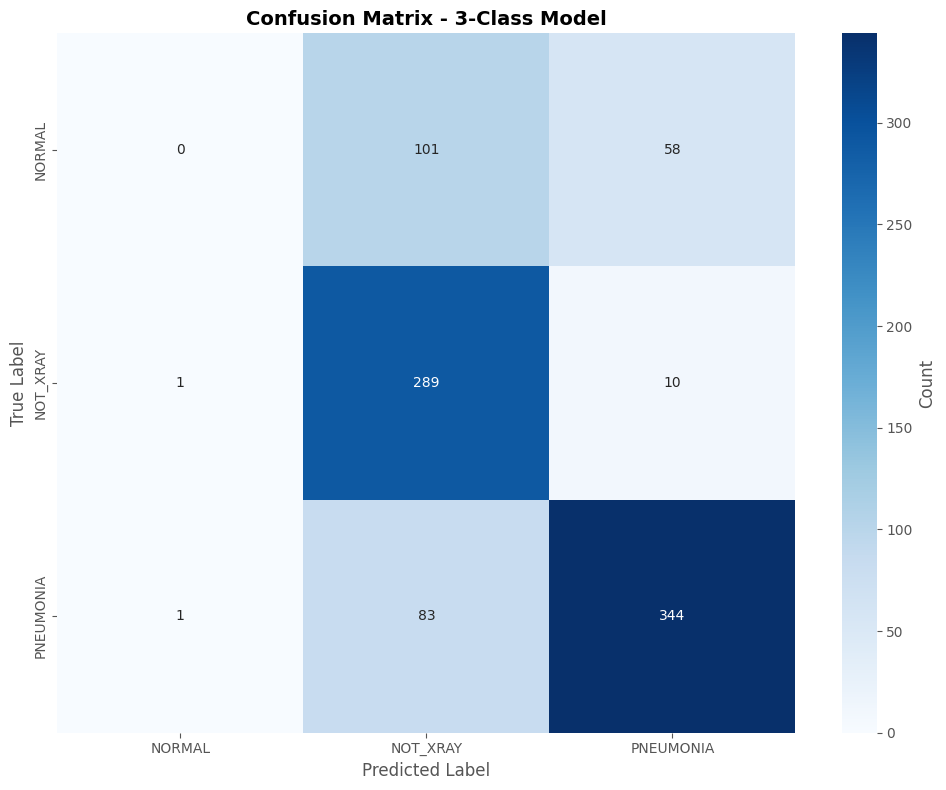


✅ Confusion matrix saved!


In [16]:
# ============================================================================
# STEP 8: EVALUATE ON TEST SET
# ============================================================================

print(f"\n{'='*70}")
print(f"EVALUATING ON TEST SET")
print(f"{'='*70}\n")

best_model = load_model(os.path.join(CHECKPOINT_DIR, 'best_model_final_3class.keras'))

test_results = best_model.evaluate(test_generator, verbose=1)
test_loss, test_acc, test_auc, test_precision, test_recall = test_results

print(f"\n{'='*70}")
print(f"Test Set Performance (3-Class Model)")
print(f"{'='*70}")
print(f"Test Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test AUC:       {test_auc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"{'='*70}\n")

# Get predictions
test_generator.reset()
y_pred_probs = best_model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Get class names
class_names = list(test_generator.class_indices.keys())
print(f"Class mapping: {dict(enumerate(class_names))}")

# Classification report
print(f"\n{'='*70}")
print(f"Classification Report")
print(f"{'='*70}")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print(f"\nConfusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - 3-Class Model', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_3class.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Confusion matrix saved!")




In [18]:

# ============================================================================
# STEP 9: SAVE FINAL MODEL
# ============================================================================

print(f"\n{'='*70}")
print(f"SAVING FINAL MODEL")
print(f"{'='*70}")

best_model.save('pneumonia_detection_3class.keras')
print("✅ Model saved as: pneumonia_detection_3class.keras")

best_model.save('pneumonia_detection_3class.h5')
print("✅ Model saved as: pneumonia_detection_3class.h5")

config = {
    'img_size': IMG_SIZE,
    'num_classes': 3,
    'class_names': class_names,
    'class_mapping': dict(enumerate(class_names)),
    'test_accuracy': float(test_acc),
    'test_auc': float(test_auc),
    'tensorflow_version': tf.__version__
}

with open('model_config_3class.json', 'w') as f:
    json.dump(config, f, indent=4)

print("✅ Configuration saved!")
print(f"{'='*70}\n")



SAVING FINAL MODEL


✅ Model saved as: pneumonia_detection_3class.keras
✅ Model saved as: pneumonia_detection_3class.h5
✅ Configuration saved!



In [19]:
# ============================================================================
# STEP 10: CREATE PREDICTION FUNCTION
# ============================================================================

def predict_image_3class(image_path, model, confidence_threshold=0.7):
    """
    Predict on ANY image - X-ray or normal photo
    
    Returns:
        - NORMAL: Healthy chest X-ray
        - PNEUMONIA: Infected chest X-ray
        - NOT_XRAY: Regular image (not a medical X-ray)
    """
    try:
        # Load and preprocess
        img = cv2.imread(image_path)
        if img is None:
            return {'success': False, 'error': 'Cannot read image'}
        
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
        img_array = img_resized / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        
        # Predict
        predictions = model.predict(img_array, verbose=0)
        predicted_class_idx = np.argmax(predictions[0])
        confidence = float(np.max(predictions[0]))
        
        # Map to class names
        class_mapping = {0: 'NORMAL', 1: 'NOT_XRAY', 2: 'PNEUMONIA'}
        predicted_label = class_mapping[predicted_class_idx]
        
        # Create message based on prediction
        if predicted_label == 'NOT_XRAY':
            if confidence >= confidence_threshold:
                message = f"📷 NOT AN X-RAY ({confidence*100:.1f}% confidence)"
                message += "\n   This appears to be a regular photo, not a medical X-ray."
            else:
                message = f"❓ Unclear image type ({confidence*100:.1f}% confidence)"
        
        elif predicted_label == 'PNEUMONIA':
            if confidence >= confidence_threshold:
                message = f"🔴 PNEUMONIA DETECTED ({confidence*100:.1f}% confidence)"
                message += "\n   ⚠️ Please consult a healthcare professional immediately!"
            else:
                message = f"⚠️ Possible pneumonia (Low confidence: {confidence*100:.1f}%)"
                message += "\n   Please get a professional medical evaluation."
        
        else:  # NORMAL
            if confidence >= confidence_threshold:
                message = f"✅ NORMAL X-RAY ({confidence*100:.1f}% confidence)"
                message += "\n   No signs of pneumonia detected."
            else:
                message = f"⚠️ Appears normal (Low confidence: {confidence*100:.1f}%)"
                message += "\n   Consider getting a professional medical evaluation."
        
        # Visualize
        plt.figure(figsize=(12, 5))
        
        # Original image
        plt.subplot(1, 2, 1)
        plt.imshow(img_rgb)
        plt.title('Uploaded Image', fontsize=12, fontweight='bold')
        plt.axis('off')
        
        # Prediction probabilities
        plt.subplot(1, 2, 2)
        class_labels = ['NORMAL', 'NOT_XRAY', 'PNEUMONIA']
        colors = ['green', 'gray', 'red']
        y_pos = np.arange(len(class_labels))
        
        plt.barh(y_pos, predictions[0], color=colors, alpha=0.7)
        plt.yticks(y_pos, class_labels)
        plt.xlabel('Confidence', fontsize=11)
        plt.title(f'Prediction: {predicted_label}', fontsize=12, fontweight='bold')
        plt.xlim([0, 1])
        
        for i, v in enumerate(predictions[0]):
            plt.text(v + 0.02, i, f'{v*100:.1f}%', va='center', fontsize=10)
        
        plt.tight_layout()
        plt.show()
        
        return {
            'success': True,
            'prediction': predicted_label,
            'confidence': confidence,
            'probabilities': {
                'NORMAL': float(predictions[0][0]),
                'NOT_XRAY': float(predictions[0][1]),
                'PNEUMONIA': float(predictions[0][2])
            },
            'message': message
        }
        
    except Exception as e:
        return {
            'success': False,
            'error': str(e),
            'message': f'❌ Error processing image: {str(e)}'
        }

print("\n✅ 3-Class prediction function created!")
print("\nUsage:")
print("  result = predict_image_3class('path/to/any_image.jpg', best_model)")
print("  print(result['message'])")





✅ 3-Class prediction function created!

Usage:
  result = predict_image_3class('path/to/any_image.jpg', best_model)
  print(result['message'])



TESTING PREDICTION FUNCTION


Testing NORMAL images:


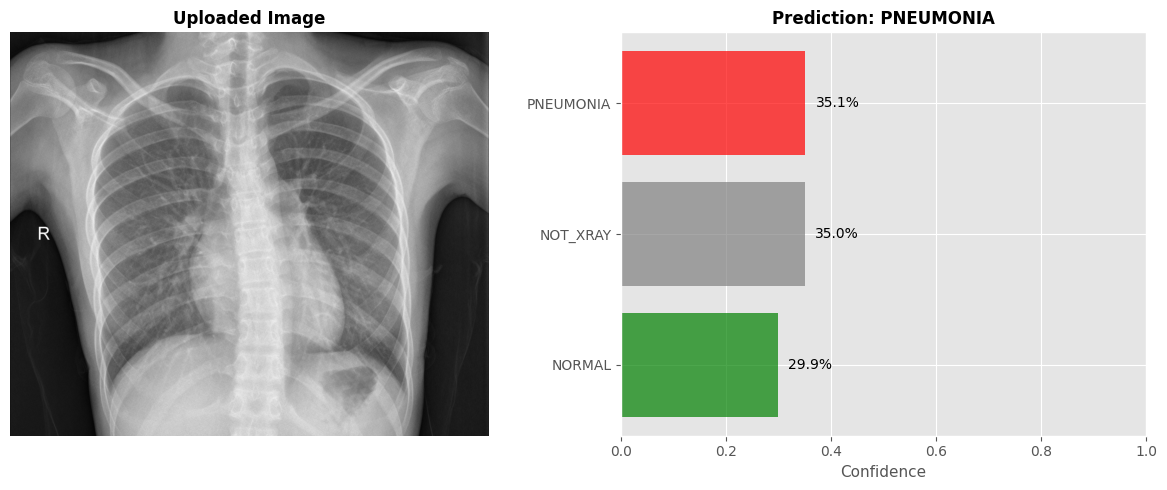


  IM-0028-0001.jpeg:
  ⚠️ Possible pneumonia (Low confidence: 35.1%)
   Please get a professional medical evaluation.


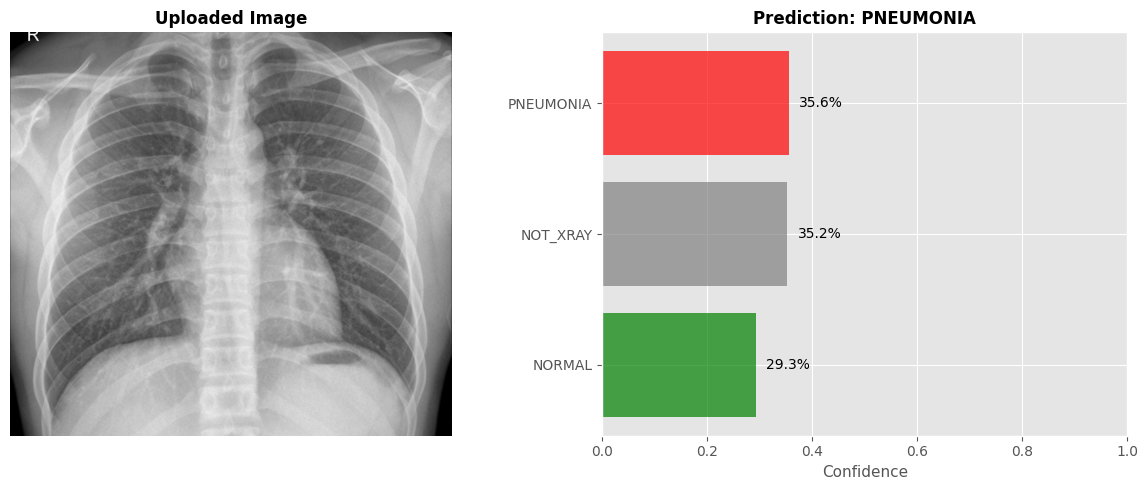


  IM-0029-0001.jpeg:
  ⚠️ Possible pneumonia (Low confidence: 35.6%)
   Please get a professional medical evaluation.

Testing PNEUMONIA images:


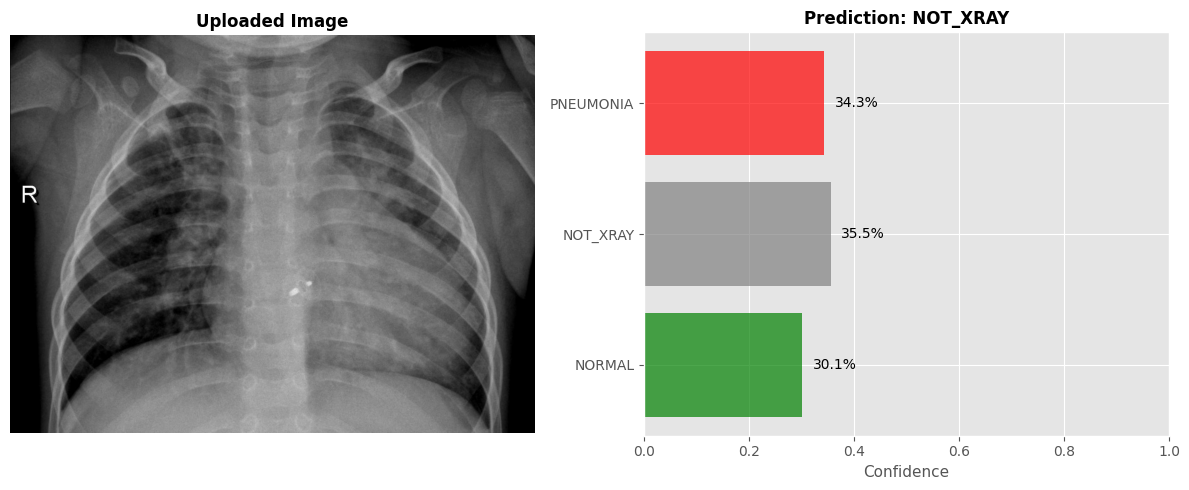


  person1002_bacteria_2933.jpeg:
  ❓ Unclear image type (35.5% confidence)


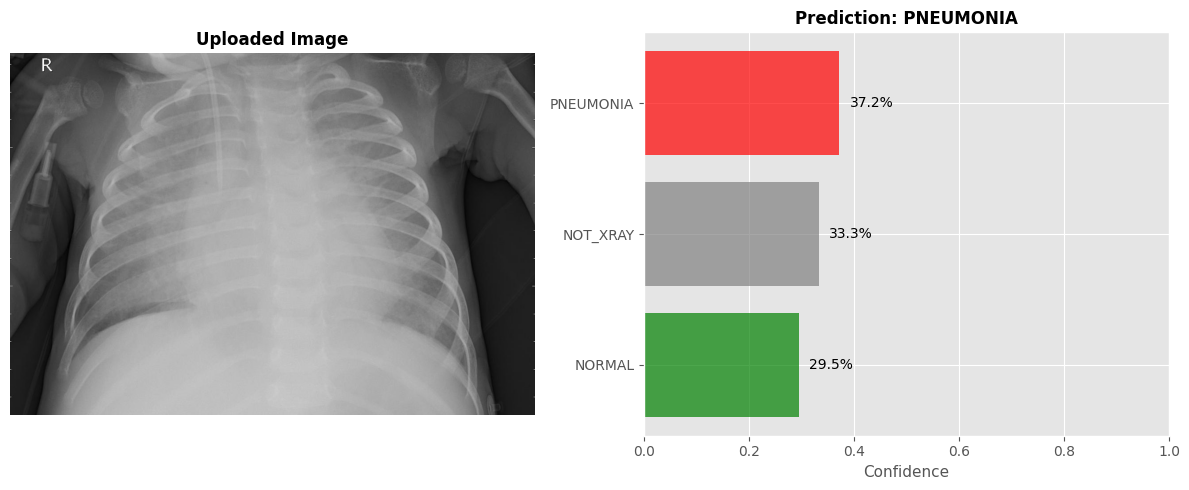


  person1004_bacteria_2935.jpeg:
  ⚠️ Possible pneumonia (Low confidence: 37.2%)
   Please get a professional medical evaluation.

Testing NOT_XRAY images:


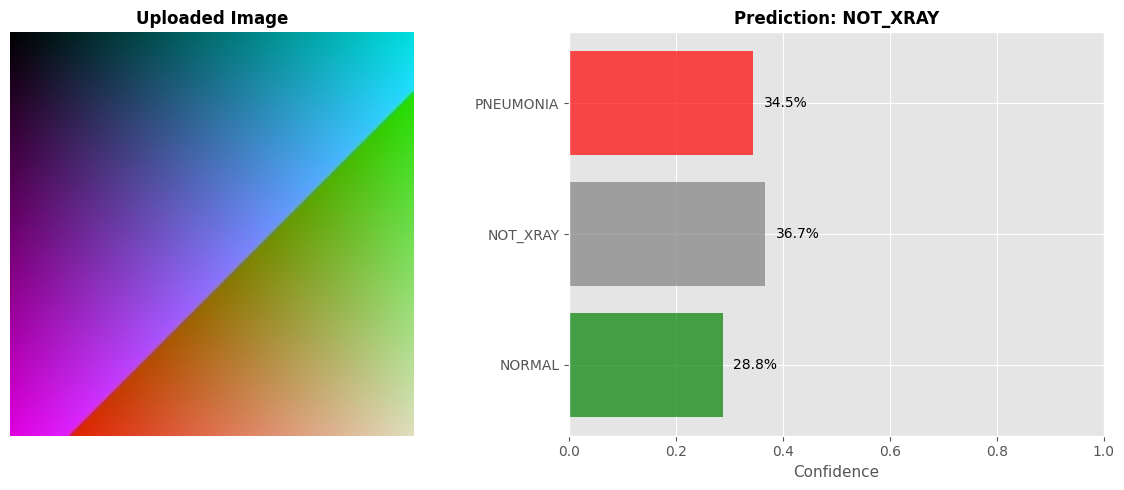


  not_xray_0000.jpg:
  ❓ Unclear image type (36.7% confidence)


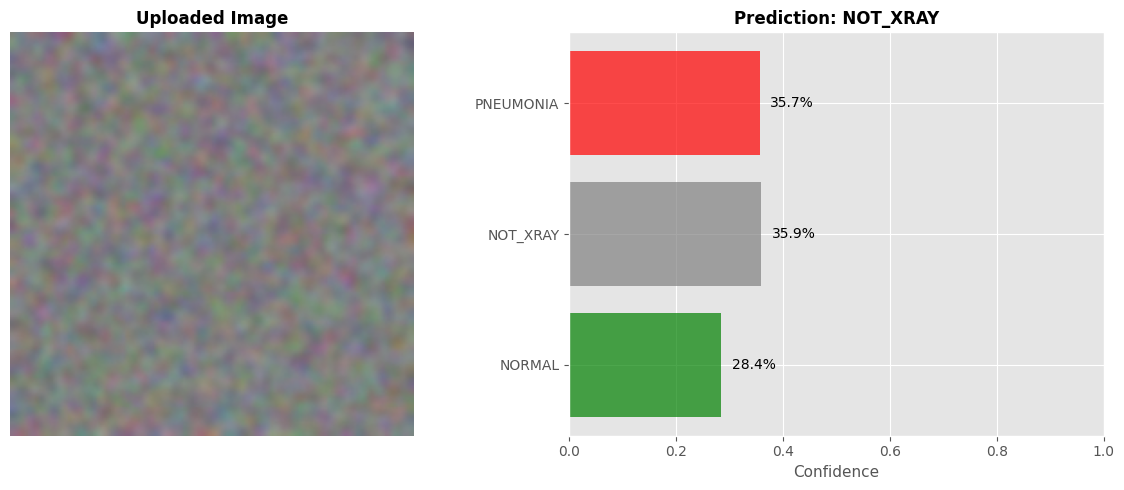


  not_xray_0001.jpg:
  ❓ Unclear image type (35.9% confidence)


In [20]:
# ============================================================================
# STEP 11: TEST THE PREDICTION FUNCTION
# ============================================================================

print(f"\n{'='*70}")
print(f"TESTING PREDICTION FUNCTION")
print(f"{'='*70}\n")

# Test on each class
test_samples = {
    'NORMAL': os.path.join(NEW_TEST, 'NORMAL'),
    'PNEUMONIA': os.path.join(NEW_TEST, 'PNEUMONIA'),
    'NOT_XRAY': os.path.join(NEW_TEST, 'NOT_XRAY')
}

for class_name, class_dir in test_samples.items():
    if os.path.exists(class_dir):
        images = os.listdir(class_dir)[:2]
        print(f"\nTesting {class_name} images:")
        for img_name in images:
            img_path = os.path.join(class_dir, img_name)
            result = predict_image_3class(img_path, best_model)
            if result['success']:
                print(f"\n  {img_name}:")
                print(f"  {result['message']}")


# ============================================================================
# FINAL SUMMARY
# ============================================================================

print(f"\n{'='*70}")
print(f"          3-CLASS PNEUMONIA DETECTION - COMPLETE!")
print(f"{'='*70}")
print(f"""
✅ Model successfully trained on 3 classes!
✅ Can now handle ANY uploaded image!

Classes:
  1. NORMAL    - Healthy chest X-ray
  2. PNEUMONIA - Infected chest X-ray
  3. NOT_XRAY  - Regular photos/images

Test Performance:
  Accuracy: {test_acc*100:.2f}%
  AUC: {test_auc:.4f}

What happens when users upload:
  📷 Selfie/Photo     → Detects as NOT_XRAY ✅
  🩺 Normal X-ray     → Detects as NORMAL ✅
  🦠 Pneumonia X-ray  → Detects as PNEUMONIA ✅

⚠️  IMPORTANT:
This is for educational purposes only.
Always consult healthcare professionals for medical decisions!

{'='*70}
""")